<a href="https://colab.research.google.com/github/marcos-mansur/load-forecast/blob/main/Notebook_2_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Files

In [2]:
df_2021 = pd.read_csv('https://raw.githubusercontent.com/marcos-mansur/load-forecast/main/Data/CARGA_ENERGIA_2021.csv', 
                      sep=';', 
                      parse_dates=['din_instante'])
df = df_2021.copy()
df.head()

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
0,N,NORTE,2021-01-01,5249.829458
1,NE,NORDESTE,2021-01-01,9828.785917
2,S,SUL,2021-01-01,8564.132540
3,SE,SUDESTE,2021-01-01,32419.959958
4,N,NORTE,2021-01-02,5585.214708


# Treat data

In [5]:
def treat_data(df,regiao='SUDESTE'):
  # create columns with day of the week, of the month and the month 
  df['val_cargaenergiamwmed'] = np.round(df['val_cargaenergiamwmed'],2)
  # dropa as ultimas 4 linhas que não tem valor de carga
  df.dropna(axis=0, how='any',inplace=True)
  # filtra os dados por região 
  df = df[df['nom_subsistema']==regiao].reset_index().drop('index',axis=1).copy()
  return df

df = treat_data(df)

# Initialize constants

In [118]:
# 30 days of validation
split_time = len(df) - 30
batch_size = 32
window_size = 45
shuffle_buffer = 20
np.random.seed(42)

print('split time = ',split_time)

split time =  296


# Split train test

In [9]:
# split_time = 296
x_train = df[df['din_instante']>'2020-12-31'][:split_time].copy().reset_index().drop('index',axis=1)
x_valid = df[df['din_instante']>'2020-12-31'][split_time:].copy().reset_index().drop('index',axis=1)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.7/dist-packages/matplotlib/pyplot.py'>

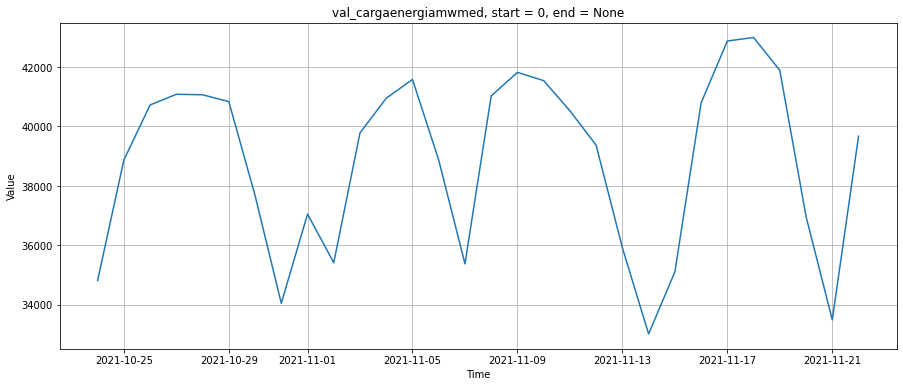

In [10]:
def plot_serie(df1,col='val_cargaenergiamwmed',start=0,end=None, title=''):
  plt.rcParams['figure.figsize'] = [15,6]
  plt.plot(df1['din_instante'][start:end],
           df1[col][start:end],)
  plt.title(title + col + ', start = '+ str(start) + ', end = ' + str(end))
  plt.xlabel("Time")
  plt.ylabel("Value")
  plt.grid(True)
  return plt


plot_serie(x_valid)

4 peaks in a month, there's definitely weekly sazonality.

# TensorFlow Dataset

In [119]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
  dataset = tf.data.Dataset.from_tensor_slices(series)
  dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)
  dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))
  dataset = dataset.shuffle(shuffle_buffer).map(lambda window: (window[:-1], window[-1]))
  dataset = dataset.batch(batch_size).prefetch(1)
  return dataset

dataset = windowed_dataset(x_train['val_cargaenergiamwmed'], window_size, batch_size, shuffle_buffer)

In [174]:
l0 = tf.keras.layers.SimpleRNN(50, return_sequences=False, kernel_initializer='normal')
l1 = tf.keras.layers.SimpleRNN(20, return_sequences=False)
# Sequential NN
model = tf.keras.models.Sequential([
    tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis = -1), input_shape=[None]),
    tf.keras.layers.BatchNormalization(),
    l0,
#    l1,
    tf.keras.layers.Dense(1),
    tf.keras.layers.Lambda(lambda x: x * 10000.0)
    ])

# compile
model.compile(loss="mse", optimizer = 'adam')
# train the NN
history = model.fit(dataset,epochs=160,verbose=0)

print("Layer weights {}".format(l0.get_weights()))

Layer weights [array([[-0.0254177 , -0.02246616,  0.02276584,  0.19679764, -0.03923476,
         0.04199852,  0.02963242, -0.07630975, -0.04734319, -0.07355021,
        -0.00348247,  0.07703307,  0.08197729, -0.03705342, -0.0082939 ,
        -0.06099745,  0.02642791, -0.05989879,  0.06315407, -0.11028156,
        -0.01015139,  0.0180166 , -0.04667776,  0.06830386,  0.08015224,
         0.05770713, -0.01370141, -0.01388791, -0.00629138,  0.03424739,
        -0.11121219, -0.00577383,  0.04358996, -0.01201746, -0.0219082 ,
         0.04464402, -0.0104893 , -0.02582399,  0.02615476,  0.05936098,
         0.01086838, -0.03569664,  0.01033572, -0.04707862, -0.07938937,
         0.06392682, -0.03093496,  0.22665979,  0.14627422, -0.05768901]],
      dtype=float32), array([[ 0.03201771,  0.12130741,  0.21265182, ..., -0.07124425,
        -0.35748708,  0.14671576],
       [ 0.02349494,  0.07782082, -0.12871675, ..., -0.24028507,
        -0.00778598, -0.07532564],
       [ 0.1934974 , -0.0620458

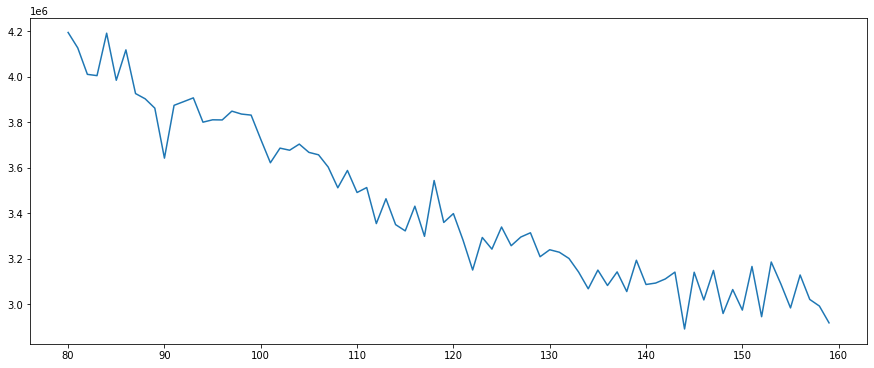

In [175]:
skip = 80
plt.plot(range(skip,len(history.history['loss'])),history.history['loss'][skip:])
#plt.plot(range(skip,len(history.history['mse'])),history.history['mse'][skip:])


# Prediction

In [176]:
forecast = []
for time in range(len(df) - window_size):
  forecast.append(model.predict(np.array(df['val_cargaenergiamwmed'][time:time + window_size])[np.newaxis]))

valid_forecast = forecast[split_time-window_size:]
results = np.array(valid_forecast)[:, 0, 0]

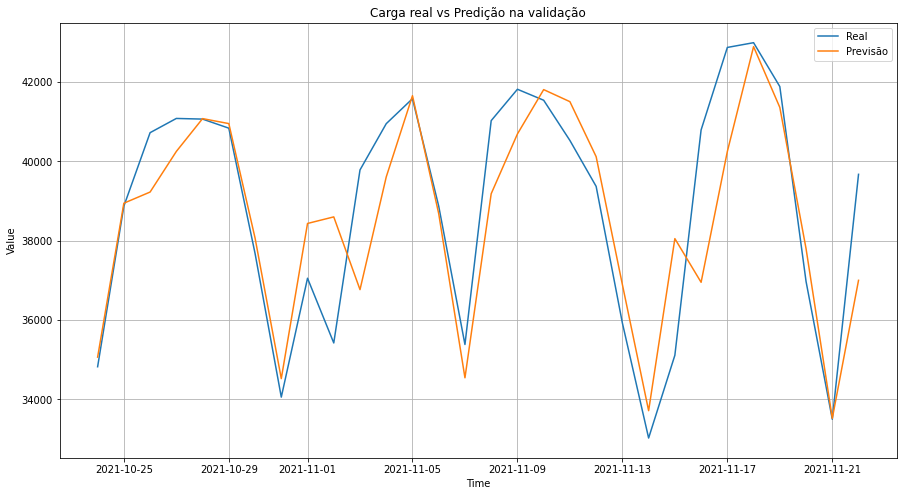

In [177]:
plt.figure(figsize=(15, 8))

plot_serie(x_valid)
plt.plot(x_valid.din_instante, results)
plt.title('Carga real vs Predição na validação')
plt.legend(['Real', 'Previsão'])

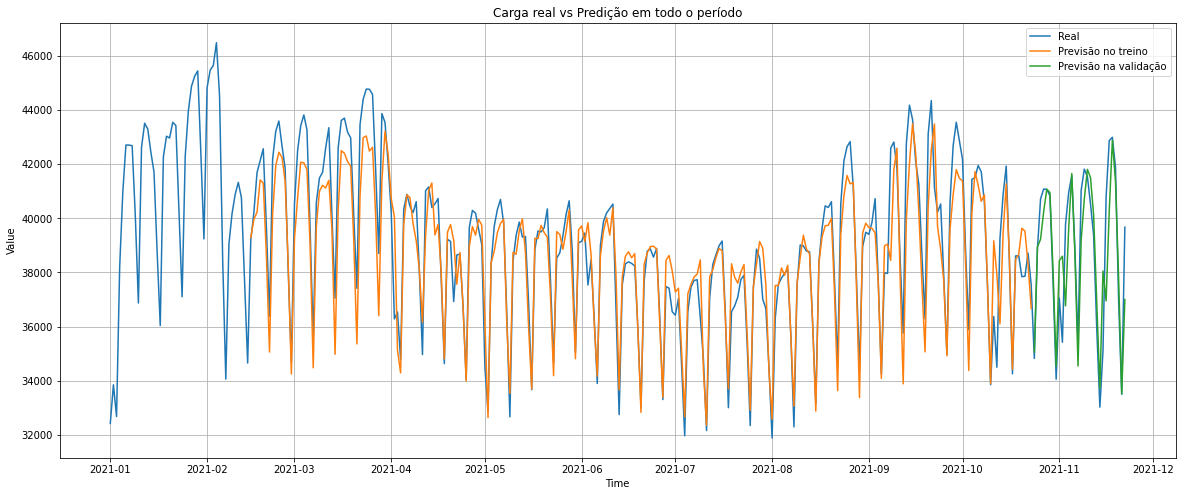

In [178]:
plt.figure(figsize=(20, 8))

plot_serie(df)
plt.plot(df.din_instante[window_size:split_time], np.array(forecast)[:split_time-window_size,0,0])
plt.plot(df.din_instante[split_time:],np.array(forecast)[split_time-window_size:,0,0])
plt.title('Carga real vs Predição em todo o período')
plt.legend(['Real', 'Previsão no treino', 'Previsão na validação'])

In [179]:
print('MAE on train: ',
      tf.keras.metrics.mean_absolute_error(
          np.array(df.val_cargaenergiamwmed[window_size:split_time]), 
          np.array(forecast)[:split_time-window_size,0,0]).numpy()
          )

print('MAE on validation: ',
      tf.keras.metrics.mean_absolute_error(
          np.array(x_valid['val_cargaenergiamwmed']), 
          results).numpy()
          )

MAE on train:  817.8983
MAE on validation:  1128.096
